# Word Cloud - Captions of cleangirl and messygirl posts

## Overview
This notebook creates two word clouds for the captions for posts of each trend.

* empty lines are ignored
* english AND german stopwords are removed (both english and german captions are likely)
* word clouds saved as ".jpg"

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

In [ ]:
df = pd.read_csv("/content/combined_clean_messy_new.csv", sep = ",")

In [ ]:
# stop word removal für english and german stop words
# because both, english and german, is represented

nltk.download("stopwords")

stopwords_en = set(stopwords.words("english"))
stopwords_de = set(stopwords.words("german"))

stopwords = stopwords_en.union(stopwords_de)
stopwords.update(["girl", "girls"])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# setting the categories represented in the category-column
categories = ["clean_girl_", "messy_girl_"]

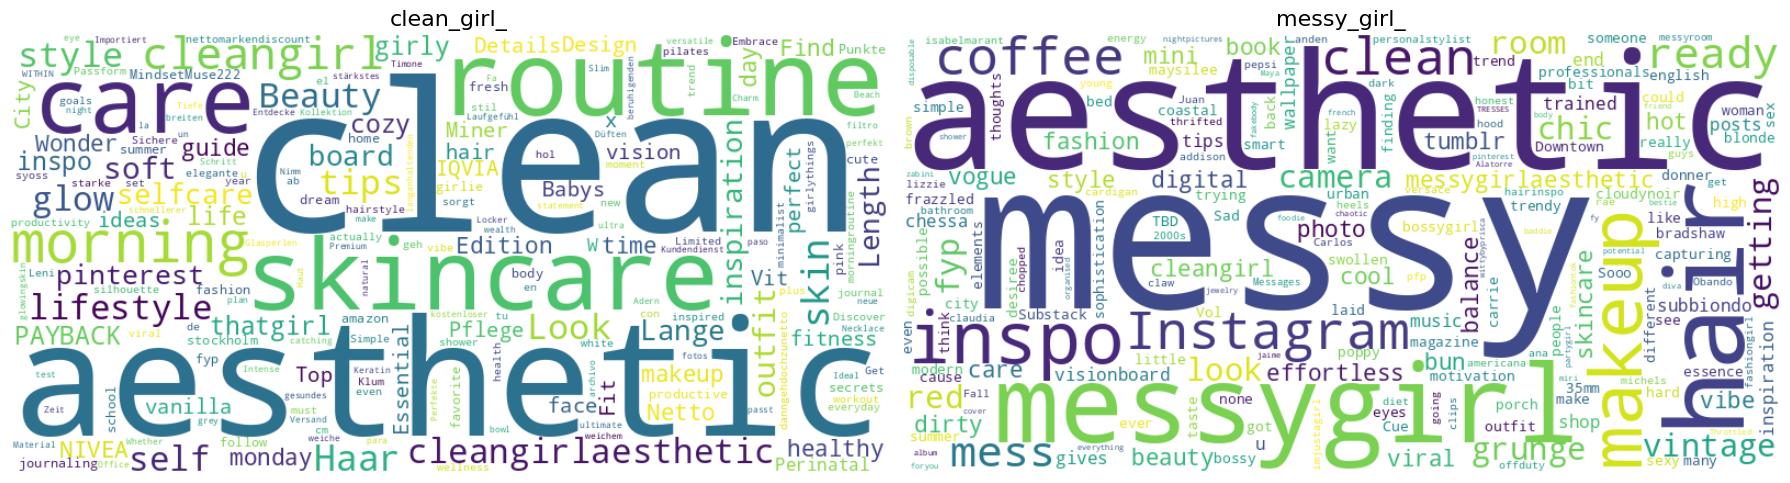

In [ ]:
# plotting the word clouds for messy girl and clean girl aesthetic
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, category in zip(axes, categories):

    # filter for categories and ignoring empty lines
    texts = df.loc[
        (df["category"] == category) &
        (df["description"].notna()),
        "description"
    ]

    # combining all descriptions for each category
    combined_text = " ".join(texts.astype(str))

    # creating the WordCloud, no words should appear more than once
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=stopwords,
        collocations=False
    ).generate(combined_text)

    # Plot
    ax.imshow(wordcloud, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{category}", fontsize=16)

plt.tight_layout()
plt.savefig("WordClouds_clean_messy.jpg") # saving the WordClouds